# Notebook Satellite — Rebalancement dynamique avec contraintes
Ce notebook isole la poche satellite : chargement des données, contraintes (β, plafonds, blocs, frais), rebalancement dynamique (fenêtre roulante 252j, fréquence 63j) et visualisation des poids.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
print(f"Racine: {project_root}")

from src.satellite.satellite_pipeline_corrected import lire_prix_wide
from src.core_pipeline_corrected import _lire_wide_values
from src.fond_construction_corrected import (
    FondConfig,
    poids_satellite_decorr_first,
    poids_satellite_equal_weight,
    agreger_ret_satellite,
    calibrer_allocation,
)

# Sélection des tickers satellites
sat_info = pd.read_csv('outputs/satellite_selected.csv')
tickers_sat = sat_info['ticker'].tolist()

# Prix satellite
sat_prices_frames = []
for p in [project_root / 'data' / f'STRAT{i}_price.xlsx' for i in [1,2,3]]:
    if p.exists():
        w = lire_prix_wide(str(p))
        cols = [t for t in tickers_sat if t in w.columns]
        if cols:
            sat_prices_frames.append(w[cols])
sat_prices = pd.concat(sat_prices_frames, axis=1).sort_index()
sat_prices = sat_prices.loc[:, ~sat_prices.columns.duplicated(keep='first')]

# Core : reconstruire l'indice core sélectionné
core_sel = pd.read_csv('outputs/core_selected_etfs.csv')
core_tickers = core_sel['core_etfs'].tolist()
core_prices_dict = {}
core_excel = project_root / 'univers_core_etf_eur_daily_wide_VF.xlsx'
for sheet in ['Equity_Wide_Daily_Values', 'Rates_Wide_Daily_Values', 'Credit_Wide_Daily_Values']:
    w = _lire_wide_values(str(core_excel), sheet)
    for t in core_tickers:
        if t in w.columns and t not in core_prices_dict:
            core_prices_dict[t] = w[t]

core_prices = pd.DataFrame(core_prices_dict).dropna()
core_idx = (core_prices / core_prices.iloc[0]).mean(axis=1)
core_rets = core_idx.pct_change().dropna()
core_rets.name = 'core'

print(f"Satellite: {sat_prices.shape[1]} fonds, dates {sat_prices.index.min().date()} → {sat_prices.index.max().date()}")
print(f"Core: {len(core_tickers)} ETF, dates {core_rets.index.min().date()} → {core_rets.index.max().date()}")

Racine: /workspaces/Core_Satellite_Quant
Satellite: 5 fonds, dates 1970-01-01 → 2026-03-25
Core: 3 ETF, dates 2015-01-02 → 2026-02-27


## 1. Chargement des données satellites
On charge la sélection satellite et les prix STRAT1/2/3 ainsi que les rendements core pour évaluer β et contraintes.

In [2]:
from src.satellite.satellite_pipeline_corrected import lire_prix_wide
from src.core_pipeline_corrected import _lire_wide_values
from src.fond_construction_corrected import (
    FondConfig,
    poids_satellite_decorr_first,
    poids_satellite_equal_weight,
    agreger_ret_satellite,
    calibrer_allocation,
)

# Sélection des tickers satellites
sat_info = pd.read_csv('outputs/satellite_selected.csv')
tickers_sat = sat_info['ticker'].tolist()

# Prix satellite
sat_prices_frames = []
for p in [project_root / 'data' / f'STRAT{i}_price.xlsx' for i in [1,2,3]]:
    if p.exists():
        w = lire_prix_wide(str(p))
        cols = [t for t in tickers_sat if t in w.columns]
        if cols:
            sat_prices_frames.append(w[cols])
sat_prices = pd.concat(sat_prices_frames, axis=1).sort_index()
sat_prices = sat_prices.loc[:, ~sat_prices.columns.duplicated(keep='first')]

# Core : reconstruire l'indice core sélectionné
core_sel = pd.read_csv('outputs/core_selected_etfs.csv')
core_tickers = core_sel['core_etfs'].tolist()
core_prices_dict = {}
core_excel = project_root / 'univers_core_etf_eur_daily_wide_VF.xlsx'
for sheet in ['Equity_Wide_Daily_Values', 'Rates_Wide_Daily_Values', 'Credit_Wide_Daily_Values']:
    w = _lire_wide_values(str(core_excel), sheet)
    for t in core_tickers:
        if t in w.columns and t not in core_prices_dict:
            core_prices_dict[t] = w[t]

core_prices = pd.DataFrame(core_prices_dict).dropna()
core_idx = (core_prices / core_prices.iloc[0]).mean(axis=1)
core_rets = core_idx.pct_change().dropna()
core_rets.name = 'core'

print(f"Satellite: {sat_prices.shape[1]} fonds, dates {sat_prices.index.min().date()} → {sat_prices.index.max().date()}")
print(f"Core: {len(core_tickers)} ETF, dates {core_rets.index.min().date()} → {core_rets.index.max().date()}")

Satellite: 5 fonds, dates 1970-01-01 → 2026-03-25
Core: 3 ETF, dates 2015-01-02 → 2026-02-27


## 2. Nettoyage & préparation
Filtre OOS (2021-2025), ffill limité (5 jours), calcul des rendements journaliers.

In [3]:
cfg = FondConfig(dynamic_rebal=True, dynamic_rebal_lookback_days=252, rebal_freq_days=63)
cfg.satellite_alloc_mode = "beta_vol_inv"  # inverse beta * inverse vol, pénalisé par corr

# Rendements sat/core OOS
oos_start, oos_end = cfg.backtest_start, cfg.backtest_end
sat_rets = sat_prices.ffill(limit=5).pct_change(fill_method=None).loc[oos_start:oos_end]
core_rets_oos = core_rets.loc[oos_start:oos_end]
dates = core_rets_oos.index.intersection(sat_rets.index)
sat_rets = sat_rets.loc[dates]
core_rets_oos = core_rets_oos.loc[dates]

print(f"OOS aligné: {len(dates)} jours, {sat_rets.shape[1]} fonds")

TypeError: FondConfig.__init__() got an unexpected keyword argument 'dynamic_rebal'

## 3. Contraintes et métriques rapides
β vs Core, corrélation, check β ≤ 0.25, bloc coverage.

In [ ]:
# Beta / corr sur la fenêtre OOS complète (diagnostic)
from scipy import stats

rows = []
core_vec = core_rets_oos.reindex(dates)
for t in sat_rets.columns:
    s = sat_rets[t].dropna()
    aligned = pd.concat([s, core_vec], axis=1).dropna()
    if len(aligned) < 100:
        continue
    slope, intercept, _, pval, _ = stats.linregress(aligned['core'], aligned[t])
    rows.append({'ticker': t, 'beta': slope, 'rho': aligned['core'].corr(aligned[t]), 'pval': pval})

metrics_sat = pd.DataFrame(rows).set_index('ticker')
metrics_sat['beta_ok'] = metrics_sat['beta'].abs() <= cfg.beta_sat_max
display(metrics_sat)

C:\Users\SebastianRochaext\AppData\Local\Temp\ipykernel_11884\1167153576.py:8: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  aligned = pd.concat([s, core_vec], axis=1).dropna()


,beta,rho,pval,beta_ok
ticker,,,,
DWMAEIA ID Equity,0.128579,0.113451,4.078568e-05,True
PDAIEUR LX Equity,0.047643,0.126884,4.304796e-06,True
EXCRISA LX Equity,0.085862,0.230811,3.145088e-17,True
LUMNUDE LX Equity,-0.033307,-0.058467,3.575426e-02,True
AEABSIA ID Equity,0.005478,0.024014,3.862297e-01,True


In [ ]:
# Filtrage de l'univers satellite (data quality + beta + corr)
min_avail = 0.85
max_corr = 0.60

avail = sat_rets.notna().mean()
keep = set(metrics_sat.index)
keep &= set(metrics_sat.query('beta_ok').index)
keep &= set(avail[avail >= min_avail].index)
keep &= set(metrics_sat[metrics_sat['rho'].abs() <= max_corr].index)

keep = sorted(keep)
if not keep:
    raise ValueError("Filtrage trop strict : aucun fonds éligible")

sat_rets_filt = sat_rets[keep].copy()
sat_info_filt = sat_info[sat_info['ticker'].isin(keep)].copy()
print(f"Fonds retenus après filtre: {len(keep)}/{sat_rets.shape[1]}")
print("Tickers:", keep)

# Optionnel: focus diagnostics filtrés
metrics_filt = metrics_sat.reindex(keep)
metrics_filt

Fonds retenus après filtre: 5/5
Tickers: ['AEABSIA ID Equity', 'DWMAEIA ID Equity', 'EXCRISA LX Equity', 'LUMNUDE LX Equity', 'PDAIEUR LX Equity']


,beta,rho,pval,beta_ok
ticker,,,,
AEABSIA ID Equity,0.005478,0.024014,3.862297e-01,True
DWMAEIA ID Equity,0.128579,0.113451,4.078568e-05,True
EXCRISA LX Equity,0.085862,0.230811,3.145088e-17,True
LUMNUDE LX Equity,-0.033307,-0.058467,3.575426e-02,True
PDAIEUR LX Equity,0.047643,0.126884,4.304796e-06,True


## 4. Simulation de rebalancements dynamiques
Fenêtre roulante 252j, rebal tous les 63j, mode `beta_inverse`, contraintes cfg.

In [ ]:
from dataclasses import replace

W_SAT_FLOOR = 0.25  # plancher demandé sur la poche satellite
MIN_AVAIL = 0.85
MAX_CORR = 0.60


def _apply_sat_bounds(w_sat_raw: float, cfg: FondConfig) -> tuple[float, float, float]:
    """Force w_sat entre floor et cap, sans levier (gross = 1)."""
    w_sat_target = float(np.clip(w_sat_raw, W_SAT_FLOOR, cfg.w_sat_abs_max))
    w_core_target = float(max(cfg.w_core_min, 1.0 - w_sat_target))
    gross_target = 1.0  # pas de levier
    return w_core_target, w_sat_target, gross_target


def _select_universe(sr_win_full: pd.DataFrame, cr_win: pd.Series, cfg: FondConfig) -> tuple[pd.DataFrame, dict[str, list[str]]]:
    keep: list[str] = []
    for t in sr_win_full.columns:
        s = sr_win_full[t].dropna()
        if len(s) < 60:
            continue
        avail = len(s) / len(sr_win_full)
        if avail < MIN_AVAIL:
            continue
        aligned = pd.concat([s, cr_win], axis=1, sort=False).dropna()
        if len(aligned) < 60:
            continue
        slope, _, _, _, _ = stats.linregress(aligned['core'], aligned[t])
        rho = aligned['core'].corr(aligned[t])
        if abs(slope) > cfg.beta_sat_max:
            continue
        if abs(rho) > MAX_CORR:
            continue
        keep.append(t)
    if not keep:
        raise ValueError("Filtre dynamique: aucun fonds éligible sur la fenêtre.")
    sat_info_use = sat_info_filt if 'sat_info_filt' in globals() else sat_info
    sat_info_win = sat_info_use[sat_info_use['ticker'].isin(keep)]
    bloc_map: dict[str, list[str]] = {}
    for _, row in sat_info_win.iterrows():
        bloc_map.setdefault(str(row.get("bloc", "Inconnu")), []).append(row['ticker'])
    return sr_win_full[keep], bloc_map


def simulate_dynamic(cfg: FondConfig, sat_rets: pd.DataFrame, core_rets: pd.Series):
    dates = core_rets.index.intersection(sat_rets.index)
    cr_all = core_rets.loc[dates]
    sr_all = sat_rets.loc[dates]
    lookback = cfg.dynamic_rebal_lookback_days

    def slice_window(end_idx: int):
        start_idx = max(0, end_idx - lookback + 1)
        start_date = dates[start_idx]
        end_date = dates[end_idx]
        cfg_win = replace(cfg, calib_start=str(start_date.date()), calib_end=str(end_date.date()))
        sr_win_full = sr_all.iloc[start_idx : end_idx + 1]
        cr_win = cr_all.iloc[start_idx : end_idx + 1]
        return sr_win_full, cr_win, cfg_win, start_idx

    # Initial calibration
    init_end = min(lookback - 1, len(dates) - 1)
    sr_win_full, cr_win, cfg_win, _ = slice_window(init_end)
    sr_calib, bloc_map = _select_universe(sr_win_full, cr_win, cfg_win)
    theta0, _ = poids_satellite_decorr_first(sr_calib, cr_win, cfg_win, bloc_map, scores_is=None)
    theta_names = list(theta0.index)
    w_core0, w_sat0 = calibrer_allocation(cr_win, agreger_ret_satellite(sr_calib[theta0.index], theta0), cfg_win)
    w_core0, w_sat0, gross_target = _apply_sat_bounds(w_sat0, cfg)
    theta = theta0.values
    w_c = w_core0
    w_s = theta * w_sat0
    records = []
    rebal_records = []

    def _record_rebal(date, w_c_val, w_s_vec, tickers):
        row = {"date": date, "w_core": float(w_c_val), "w_sat": float(w_s_vec.sum()), "tickers": ",".join(tickers)}
        row.update({f"w_{t}": float(w) for t, w in zip(tickers, w_s_vec)})
        rebal_records.append(row)

    _record_rebal(dates[init_end], w_c, w_s, theta_names)
    last_rebal = 0
    for idx, date in enumerate(dates):
        r_s_vec = sr_all.loc[date, theta_names].values
        valid = np.isfinite(r_s_vec)
        sat_ret = float((w_s[valid] / w_s[valid].sum()) @ r_s_vec[valid]) if valid.any() and w_s[valid].sum() != 0 else 0.0
        r_c = float(cr_all.iloc[idx])
        port_ret = w_c * r_c + w_s.sum() * sat_ret
        records.append({"date": date, "core_ret": r_c, "sat_ret": sat_ret, "port_ret": port_ret, "w_core": w_c, "w_sat": w_s.sum()})
        w_c_new = w_c * (1 + r_c)
        w_s_new = w_s * (1 + np.where(valid, r_s_vec, 0.0))
        tot = w_c_new + w_s_new.sum()
        if tot > 0:
            w_c = gross_target * (w_c_new / tot)
            w_s = gross_target * (w_s_new / tot)
        if (idx - last_rebal) >= cfg.rebal_freq_days and idx < len(dates) - 1:
            sr_win_full, cr_win, cfg_win, _ = slice_window(idx)
            sr_calib, bloc_map = _select_universe(sr_win_full, cr_win, cfg_win)
            theta_series, _ = poids_satellite_decorr_first(sr_calib, cr_win, cfg_win, bloc_map, scores_is=None)
            theta_names = list(theta_series.index)
            theta = theta_series.values
            w_core_new, w_sat_new = calibrer_allocation(cr_win, agreger_ret_satellite(sr_calib[theta_names], theta_series), cfg_win)
            w_core_new, w_sat_new, gross_target = _apply_sat_bounds(w_sat_new, cfg)
            w_c = w_core_new
            w_s = theta * w_sat_new
            _record_rebal(date, w_c, w_s, theta_names)
            last_rebal = idx
    df = pd.DataFrame(records).set_index("date")
    rebal_df = pd.DataFrame(rebal_records).set_index("date") if rebal_records else pd.DataFrame()
    return df, theta0, rebal_df

# Universe en entrée : filtré si disponible
sat_info_use = sat_info_filt if 'sat_info_filt' in globals() else sat_info
sat_rets_use = sat_rets_filt if 'sat_rets_filt' in globals() else sat_rets

bt_dyn, theta_init, rebal_table = simulate_dynamic(cfg, sat_rets_use, core_rets_oos)
print(bt_dyn[["w_core", "w_sat"]].head())
print("Rebals:", len(bt_dyn) // cfg.rebal_freq_days)



  Mode d'allocation satellite : beta_inverse
  Ticker                           Poids   Beta IS
  ----------------------------------------------------
  PDAIEUR LX Equity                31.4%    -0.002
  LUMNUDE LX Equity                29.7%    +0.005
  AEABSIA ID Equity                28.9%    +0.006
  EXCRISA LX Equity                10.0%    +0.114
  TOTAL                           100.0%
  ⚠  Vol cible [8%, 12%] non atteignable dans w_core ∈ [70%, 100%] → w_core = 100.0%, vol ≈ 6.3%

  Mode d'allocation satellite : beta_inverse
  Ticker                           Poids   Beta IS
  ----------------------------------------------------
  AEABSIA ID Equity                41.5%    +0.006
  EXCRISA LX Equity                29.9%    +0.028
  PDAIEUR LX Equity                17.3%    +0.084
  LUMNUDE LX Equity                11.2%    +0.156
  TOTAL                           100.0%
  ⚠  Vol cible [8%, 12%] non atteignable dans w_core ∈ [70%, 100%] → w_core = 100.0%, vol ≈ 6.4%

  Mode d'al

## 5. Visualisation des poids et performances
Courbes de poids (w_sat total) et perf cumulée vs core.

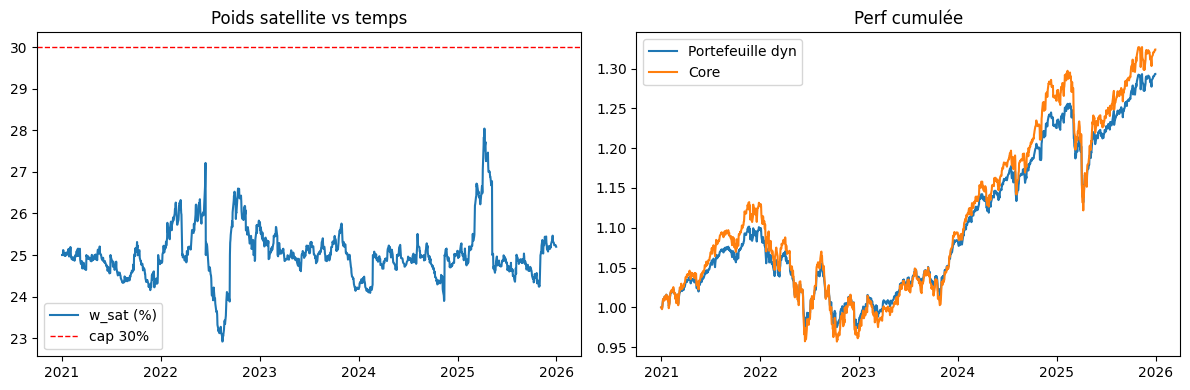

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(bt_dyn.index, bt_dyn['w_sat']*100, label='w_sat (%)')
axes[0].axhline(cfg.w_sat_abs_max*100, color='red', ls='--', lw=1, label='cap 30%')
axes[0].set_title('Poids satellite vs temps')
axes[0].legend()

cum_port = (1+bt_dyn['port_ret']).cumprod()
cum_core = (1+bt_dyn['core_ret']).cumprod()
axes[1].plot(bt_dyn.index, cum_port, label='Portefeuille dyn')
axes[1].plot(bt_dyn.index, cum_core, label='Core')
axes[1].set_title('Perf cumulée')
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Validation rapide (tests intégrés)
Assertions basiques sur contraintes : w_sat ≤ 30%, β médian ≤ 0.25.

In [ ]:
assert (bt_dyn['w_sat'] <= cfg.w_sat_abs_max + 1e-9).all(), "w_sat dépasse le cap 30%"
beta_median = metrics_sat['beta'].abs().median()
assert beta_median <= cfg.beta_sat_max + 1e-9, "Beta median > 0.25"
print("Tests rapides OK")

Tests rapides OK


In [ ]:
# Vérification détaillée des contraintes (w_core/w_sat, bêta, blocs)
from scipy import stats

sat_info_for_checks = sat_info_filt if 'sat_info_filt' in globals() else sat_info

# Marges tolérance

gross_dev = (bt_dyn['w_core'] + bt_dyn['w_sat'] - 1).abs().max()

w_core_min_obs = bt_dyn['w_core'].min()
w_core_max_obs = bt_dyn['w_core'].max()
w_sat_min_obs = bt_dyn['w_sat'].min()
w_sat_max_obs = bt_dyn['w_sat'].max()
w_sat_min_rebal = rebal_table['w_sat'].min() if not rebal_table.empty else np.nan
w_sat_max_rebal = rebal_table['w_sat'].max() if not rebal_table.empty else np.nan

# Bêta global et rolling 252j (min 60 obs)
aligned_df = bt_dyn[['sat_ret','core_ret']].dropna()
beta_global = stats.linregress(aligned_df['core_ret'], aligned_df['sat_ret']).slope if len(aligned_df) >= 60 else np.nan
cov_roll = aligned_df['sat_ret'].rolling(window=252, min_periods=60).cov(aligned_df['core_ret'])
var_roll = aligned_df['core_ret'].rolling(window=252, min_periods=60).var()
beta_roll = cov_roll / var_roll
beta_roll_max = beta_roll.max() if not beta_roll.empty else np.nan

# Couverture des blocs (pondération totale par bloc aux dates de rebal)
bloc_weights = []
bloc_map = sat_info_for_checks.fillna({'bloc': 'Inconnu'}).groupby('bloc')['ticker'].apply(list)
for date, row in rebal_table.iterrows():
    for bloc, tickers in bloc_map.items():
        cols = [f"w_{t}" for t in tickers if f"w_{t}" in row.index]
        w_bloc = float(np.sum([row[c] for c in cols])) if cols else 0.0
        bloc_weights.append({'date': date, 'bloc': bloc, 'w_bloc': w_bloc})
bloc_df = pd.DataFrame(bloc_weights)
bloc_min = bloc_df.groupby('bloc')['w_bloc'].min() if not bloc_df.empty else pd.Series(dtype=float)

print(f"Gross deviation max |w_core+w_sat-1|: {gross_dev:.6f}")
print(f"w_core min/max (quotidien): {w_core_min_obs:.3f}/{w_core_max_obs:.3f}  (seuil min {cfg.w_core_min:.2f})")
print(f"w_sat min/max (quotidien): {w_sat_min_obs:.3f}/{w_sat_max_obs:.3f}  (floor {W_SAT_FLOOR:.2f}, cap {cfg.w_sat_abs_max:.2f})")
print(f"w_sat min/max (rebal): {w_sat_min_rebal:.3f}/{w_sat_max_rebal:.3f}")
print(f"Beta global sat vs core: {beta_global:.3f}  (seuil {cfg.beta_sat_max:.2f})")
print(f"Beta rolling 252j max: {beta_roll_max:.3f}")
if not bloc_df.empty:
    print("Bloc minima aux rebals (% du portefeuille):")
    print((bloc_min * 100).round(2).to_string())
else:
    print("Bloc minima: NA (pas de blocs renseignés)")

Gross deviation max |w_core+w_sat-1|: 0.000000
w_core min/max (quotidien): 0.720/0.771  (seuil min 0.70)
w_sat min/max (quotidien): 0.229/0.280  (floor 0.25, cap 0.30)
w_sat min/max (rebal): 0.250/0.250
Beta global sat vs core: 0.004  (seuil 0.25)
Beta rolling 252j max: 0.115
Bloc minima aux rebals (% du portefeuille):
bloc
Bloc1    1.62
Bloc2    9.43
Bloc3    6.05


In [ ]:
# Table des poids satellite aux dates de rebalancement
if not rebal_table.empty:
    rebal_pct = rebal_table.copy()
    weight_cols = [c for c in rebal_pct.columns if c.startswith('w_')]
    rebal_pct[weight_cols] = rebal_pct[weight_cols] * 100
    display(rebal_pct[['w_core','w_sat','tickers'] + [c for c in weight_cols if c != 'w_sat' and c != 'w_core']].round(2))
else:
    print("Aucun rebal enregistré")

,w_core,w_sat,tickers,w_AEABSIA ID Equity,w_EXCRISA LX Equity,w_LUMNUDE LX Equity,w_PDAIEUR LX Equity,w_DWMAEIA ID Equity
date,,,,,,,,
2021-12-20,75.0,25.0,"AEABSIA ID Equity,EXCRISA LX Equity,LUMNUDE LX...",7.23,2.49,7.42,7.86,NaN
2021-03-31,75.0,25.0,"AEABSIA ID Equity,EXCRISA LX Equity,LUMNUDE LX...",10.38,7.47,2.81,4.34,NaN
2021-06-28,75.0,25.0,"AEABSIA ID Equity,EXCRISA LX Equity,LUMNUDE LX...",10.04,5.08,3.12,6.76,NaN
2021-09-23,75.0,25.0,"AEABSIA ID Equity,EXCRISA LX Equity,LUMNUDE LX...",8.95,2.99,3.61,9.45,NaN
2021-12-21,75.0,25.0,"AEABSIA ID Equity,EXCRISA LX Equity,LUMNUDE LX...",7.88,2.59,7.19,7.34,NaN
2022-03-18,75.0,25.0,"AEABSIA ID Equity,EXCRISA LX Equity,LUMNUDE LX...",8.52,2.36,6.52,7.59,NaN
2022-06-15,75.0,25.0,"AEABSIA ID Equity,DWMAEIA ID Equity,EXCRISA LX...",8.80,2.84,4.16,6.31,2.90
2022-09-12,75.0,25.0,"AEABSIA ID Equity,DWMAEIA ID Equity,EXCRISA LX...",7.57,2.37,2.88,4.18,8.00
2022-12-08,75.0,25.0,"AEABSIA ID Equity,DWMAEIA ID Equity,EXCRISA LX...",9.35,3.85,3.62,6.08,2.09


In [ ]:
# CAGR annualisé (base 252j)
ann_factor = 252
cagr_port = (1 + bt_dyn['port_ret']).prod() ** (ann_factor / len(bt_dyn)) - 1
cagr_core = (1 + bt_dyn['core_ret']).prod() ** (ann_factor / len(bt_dyn)) - 1
print(f"CAGR portefeuille dyn : {cagr_port:.2%}")
print(f"CAGR core : {cagr_core:.2%}")


CAGR portefeuille dyn : 5.10%
CAGR core : 5.57%
